Rows: 123
TECH_FILTER: Nuclear
Unique i: ['Nuclear']


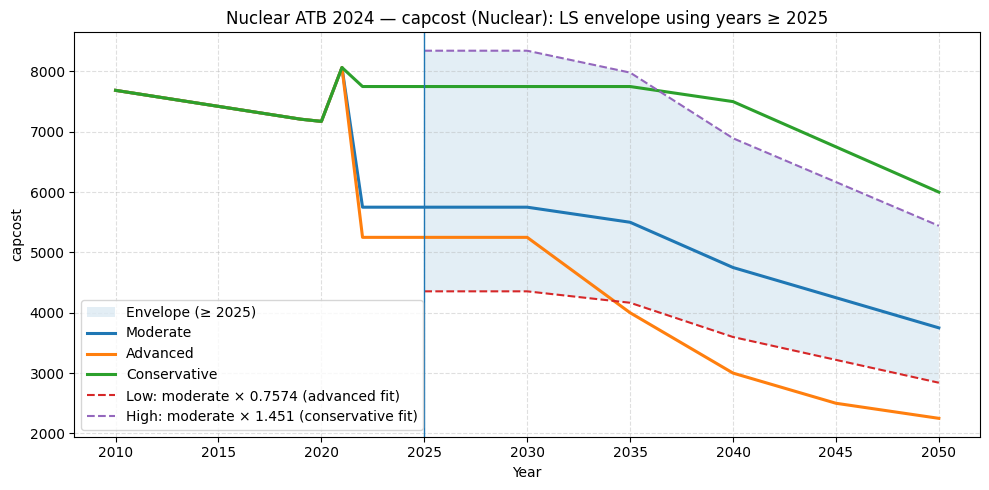

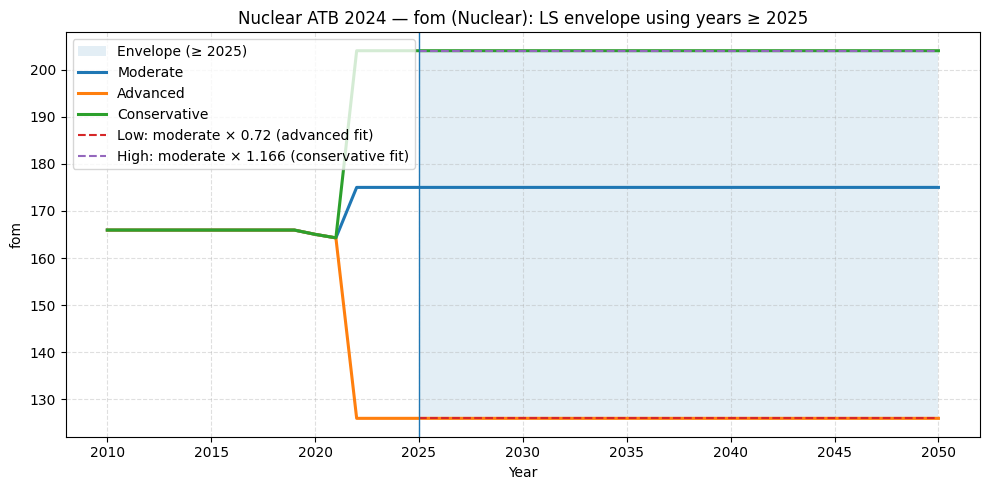

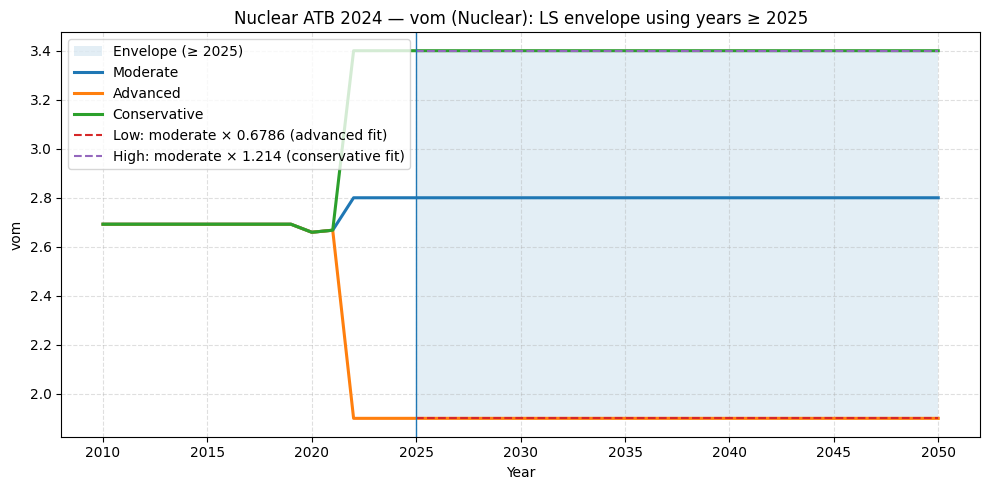

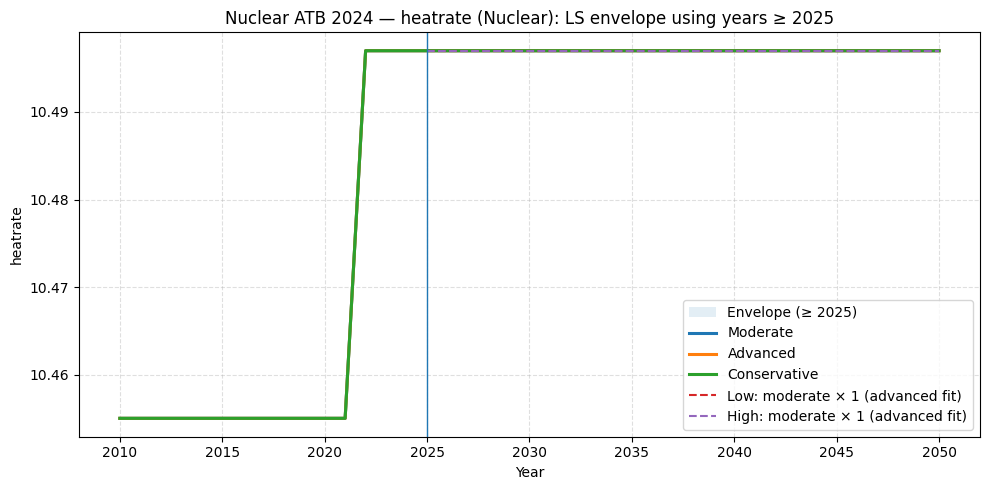

,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,capcost,0.757446,1.451063,0.757446,1.451063,advanced,conservative,26,2025,2050
1,fom,0.720000,1.165714,0.720000,1.165714,advanced,conservative,26,2025,2050
2,vom,0.678571,1.214286,0.678571,1.214286,advanced,conservative,26,2025,2050
3,heatrate,1.000000,1.000000,1.000000,1.000000,advanced,advanced,26,2025,2050


Saved: nuclear_envelope_multipliers.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# CONFIG (NUCLEAR ATB 2024)
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/nuclear_ATB_2024_advanced.csv#/",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/nuclear_ATB_2024_moderate.csv#/",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/nuclear_ATB_2024_conservative.csv#/",
}

# If file contains multiple technologies in column `i`, set this.
# Otherwise leave None to auto-detect (if exactly one unique value in moderate).
TECH_FILTER = None  # e.g., "Nuclear"

# These columns exist in your sample
METRICS = ["capcost", "fom", "vom", "heatrate"]

# Fit multipliers using years >= START_YEAR, then show envelope from START_YEAR onward
START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "nuclear_envelope_multipliers.csv"


# ---------------------------
# HELPERS
# ---------------------------
def _clean_url(url: str) -> str:
    """Remove URL fragments like '#/' that can break pd.read_csv over HTTP."""
    return url.split("#", 1)[0]

def load_from_urls(urls: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(_clean_url(url))
        df["scenario"] = scen
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Ensure year is int
    out["t"] = pd.to_numeric(out["t"], errors="coerce")
    out = out.dropna(subset=["t"]).copy()
    out["t"] = out["t"].astype(int)

    # Ensure metrics are numeric where possible
    for col in METRICS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Auto-detect a single tech if TECH_FILTER is None
    global TECH_FILTER
    if "i" in out.columns and TECH_FILTER is None:
        techs = out.loc[out["scenario"] == "moderate", "i"].dropna().unique().tolist()
        if len(techs) == 1:
            TECH_FILTER = techs[0]

    # Filter to one technology if requested / detected
    if "i" in out.columns and TECH_FILTER is not None:
        out = out[out["i"] == TECH_FILTER].copy()

    return out.sort_values(["scenario", "t"]).reset_index(drop=True)


def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    """
    Least-squares multiplier m minimizing || m*moderate - target ||^2
    => m = (moderate·target) / (moderate·moderate)
    """
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)


def envelope_multipliers(df: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for metric='{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }


def plot_with_envelope(df: pd.DataFrame, metric: str, start_year: int = 2025):
    info = envelope_multipliers(df, metric, start_year=start_year)

    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")

    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--",
             label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--",
             label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    title_i = f" ({TECH_FILTER})" if ("i" in df.columns and TECH_FILTER is not None) else ""
    plt.title(f"Nuclear ATB 2024 — {metric}{title_i}: LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info


# ---------------------------
# RUN
# ---------------------------
df = load_from_urls(FILE_URLS)
print("Rows:", len(df))
if "i" in df.columns:
    print("TECH_FILTER:", TECH_FILTER)
    print("Unique i:", df["i"].unique())

results = []
for m in METRICS:
    results.append(plot_with_envelope(df, m, start_year=START_YEAR))

res = pd.DataFrame(results)
display(res)

if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)


In [2]:
import numpy as np
import pandas as pd
import os

# ============================
# SETTINGS
# ============================
N_SAMPLES   = 2
RANDOM_SEED = 42
SAMPLE_METRICS = ["capcost", "fom", "vom"]     # heatrate is constant, do NOT sample
OUT_DIR = "nuclear_ATB_2024_samples"           # folder to write per-sample csvs

os.makedirs(OUT_DIR, exist_ok=True)

# ============================
# 1) Bounds from envelope table `res`
# ============================
_bounds_df = res.loc[res["metric"].isin(SAMPLE_METRICS), ["metric", "low_mult", "high_mult"]].copy()
_missing = set(SAMPLE_METRICS) - set(_bounds_df["metric"].unique())
if _missing:
    raise ValueError(f"Missing envelope bounds in res for metrics: {_missing}")

BOUNDS = {r["metric"]: (float(r["low_mult"]), float(r["high_mult"])) for _, r in _bounds_df.iterrows()}

# ============================
# 2) Baseline = moderate Nuclear trajectory
# ============================
base = df.loc[df["scenario"].eq("moderate")].copy()

# keep TECH_FILTER logic consistent (if you used it earlier)
if "i" in base.columns and TECH_FILTER is not None:
    base = base.loc[base["i"].eq(TECH_FILTER)].copy()

# If multiple techs exist and TECH_FILTER=None, fail (prevents mixing)
if "i" in base.columns and TECH_FILTER is None:
    uniq = base["i"].unique()
    if len(uniq) != 1:
        raise ValueError(f"Multiple technologies found in moderate: {uniq}. Set TECH_FILTER.")
    BASE_TECH = str(uniq[0])
else:
    BASE_TECH = str(TECH_FILTER) if TECH_FILTER is not None else "Nuclear"

# We will FORCE output `i` to exactly match GitHub file format (typically "Nuclear")
# If your GitHub file uses a different exact string, set OUTPUT_TECH_NAME accordingly.
OUTPUT_TECH_NAME = "Nuclear"

# Clean/sort
base["t"] = pd.to_numeric(base["t"], errors="coerce")
base = base.dropna(subset=["t"]).copy()
base["t"] = base["t"].astype(int)
base = base.sort_values("t").reset_index(drop=True)

need_cols = ["t"] + METRICS
missing_cols = set(need_cols) - set(base.columns)
if missing_cols:
    raise ValueError(f"Baseline moderate data missing columns: {sorted(missing_cols)}")

base_out = base[need_cols].copy()
base_out.insert(0, "i", OUTPUT_TECH_NAME)  # EXACT output schema like GitHub

# mask for applying multipliers only after START_YEAR (>= 2025)
mask = base_out["t"] >= int(START_YEAR)

# ============================
# 3) Sample multipliers (list format)
# ============================
rng = np.random.default_rng(RANDOM_SEED)

samples = []
for k in range(1, N_SAMPLES + 1):
    d = {"sample_id": k}
    for m in SAMPLE_METRICS:
        lo, hi = BOUNDS[m]
        d[m] = float(rng.uniform(lo, hi))
    samples.append(d)

print("Sample multipliers (list format):")
print(samples)

# ============================
# 4) Write ONE CSV PER SAMPLE (GitHub format)
# ============================
all_runs = [] # Initialize list to collect all sample dataframes
for s in samples:
    df_s = base_out.copy()

    # Assign unique sample ID to 'i' column
    df_s["i"] = f"{OUTPUT_TECH_NAME}_s{s['sample_id']:03d}"

    # apply sampled multipliers only for years >= START_YEAR
    for m in SAMPLE_METRICS:
        df_s.loc[mask, m] = df_s.loc[mask, m].astype(float) * float(s[m])

    # heatrate is untouched automatically since it's not in SAMPLE_METRICS

    # (optional rounding – remove if you want raw floats)
    # df_s["capcost"]  = df_s["capcost"].round(6)
    # df_s["fom"]      = df_s["fom"].round(10)
    # df_s["vom"]      = df_s["vom"].round(10)
    # df_s["heatrate"] = df_s["heatrate"].round(3)

    # exact column order like GitHub
    df_s = df_s[["i", "t", "capcost", "fom", "vom", "heatrate"]]

    all_runs.append(df_s) # Collect the dataframe

    out_path = os.path.join(OUT_DIR, f"nuclear_ATB_2024_sample_{s['sample_id']:03d}.csv")
    df_s.to_csv(out_path, index=False)

out_df = pd.concat(all_runs, ignore_index=True) # Concatenate all collected dataframes into out_df

print(f"\nWrote {N_SAMPLES} CSV files to folder: {OUT_DIR}")
print("Example file:", os.path.join(OUT_DIR, "nuclear_ATB_2024_sample_001.csv"))

Sample multipliers (list format):
[{'sample_id': 1, 'capcost': 1.2942752347092958, 'fom': 0.9156143902894862, 'vom': 1.1385345999525267}, {'sample_id': 2, 'capcost': 1.2411524745896392, 'fom': 0.7619761893442095, 'vom': 1.2012262598054053}]

Wrote 2 CSV files to folder: nuclear_ATB_2024_samples
Example file: nuclear_ATB_2024_samples/nuclear_ATB_2024_sample_001.csv


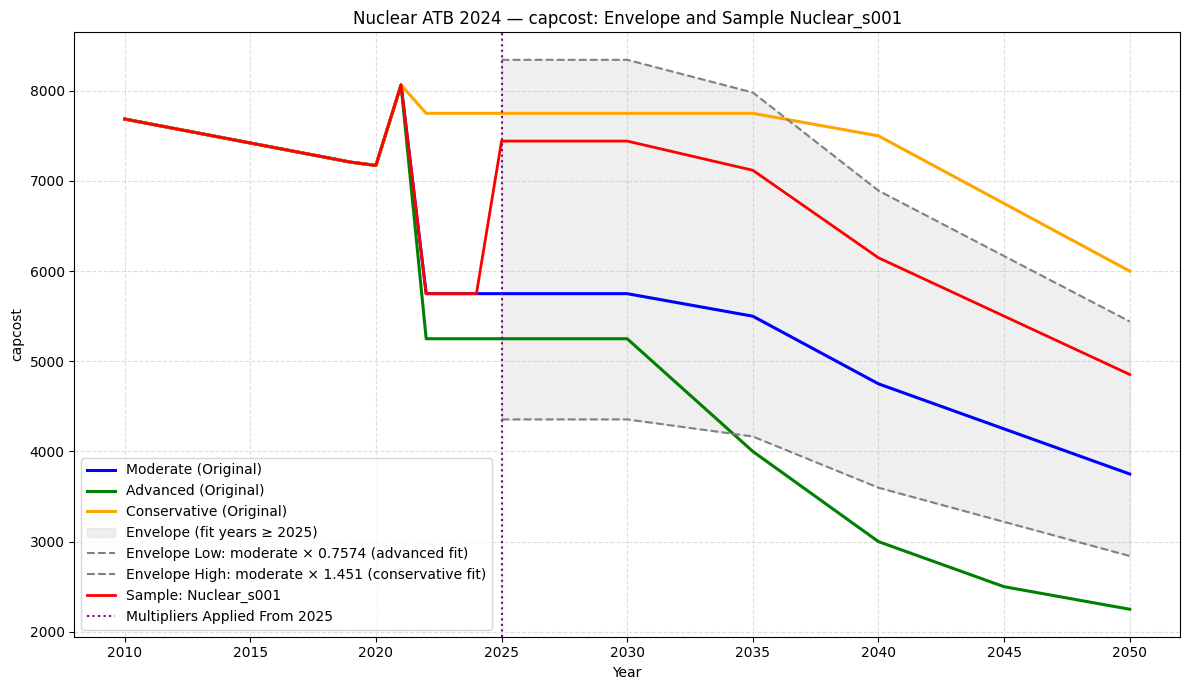

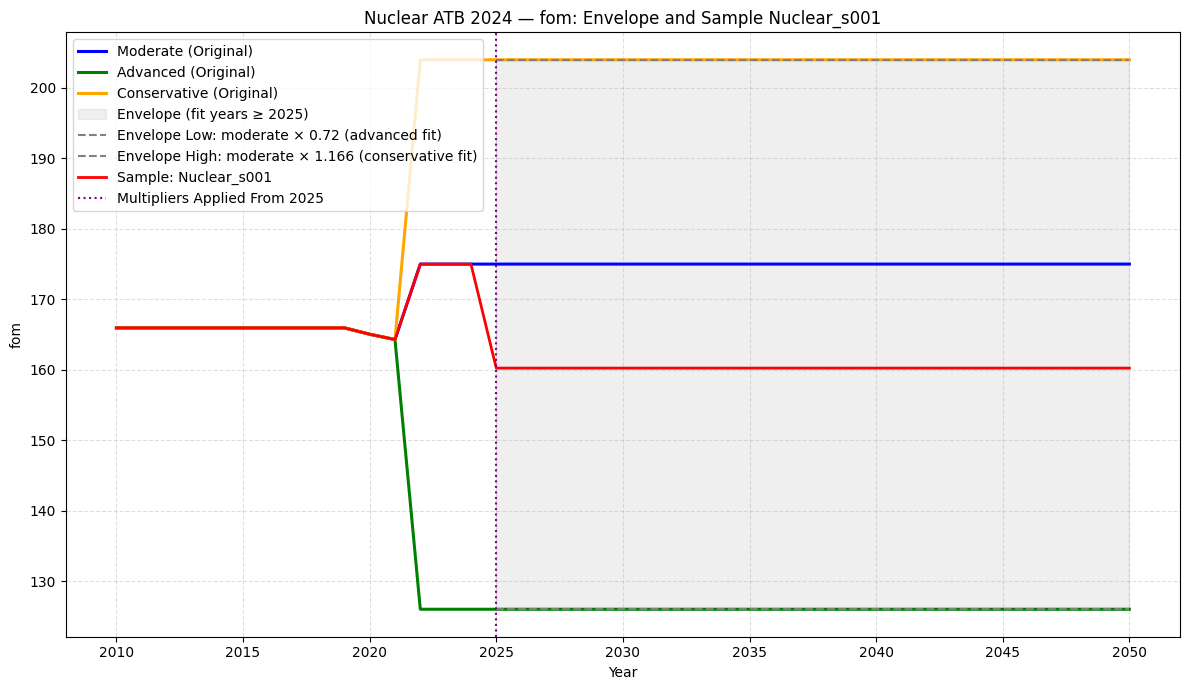

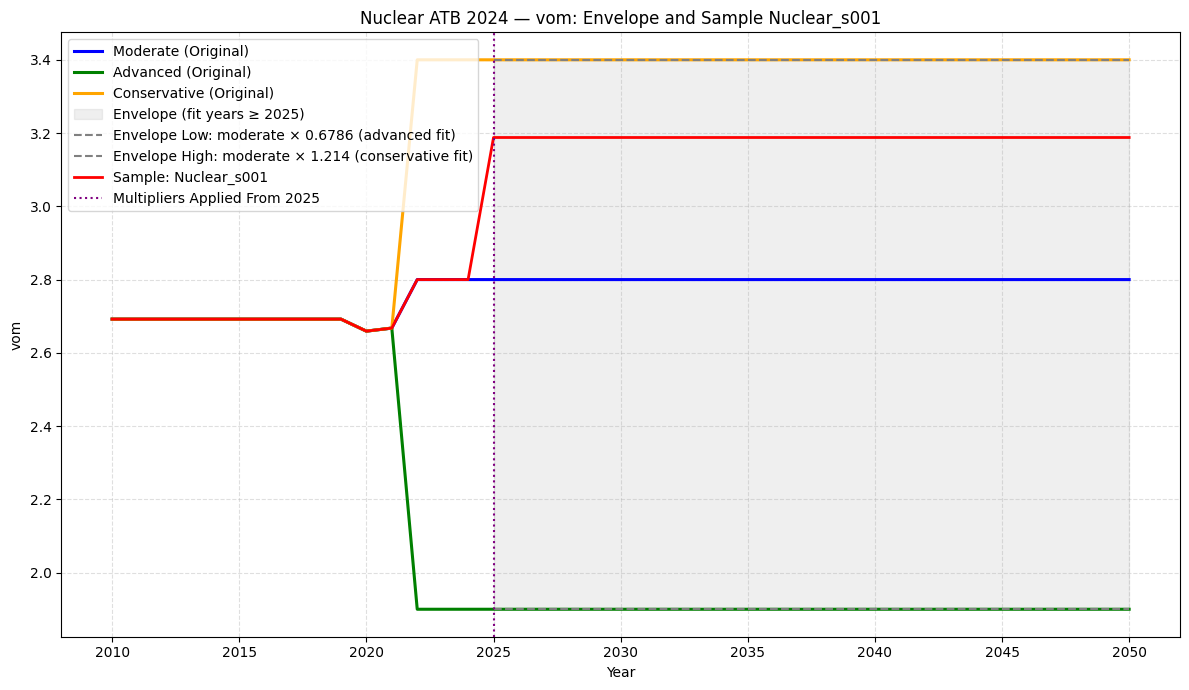

In [3]:
import matplotlib.pyplot as plt

# Choose a sample to visualize (e.g., the first one generated)
sample_to_plot = 'Nuclear_s001'

# Iterate through the metrics the user wants to plot
for metric_to_plot in ['capcost', 'fom', 'vom']:

    # Get the original 'moderate', 'advanced', 'conservative' scenario data
    piv = (df[["t", "scenario", metric_to_plot]]
           .dropna(subset=["t", metric_to_plot])
           .pivot(index="t", columns="scenario", values=metric_to_plot)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    adv_all = piv["advanced"]
    con_all = piv["conservative"]

    # Get the envelope multipliers from the 'res' DataFrame
    info_metric = res[res['metric'] == metric_to_plot].iloc[0]
    low_mult = info_metric['low_mult']
    high_mult = info_metric['high_mult']
    low_ref = info_metric['low_ref']
    high_ref = info_metric['high_ref']

    env_low = M_all * low_mult
    env_high = M_all * high_mult

    mask_fit_window = years >= START_YEAR
    yrs_env = years[mask_fit_window]

    # Get the data for the selected sample
    # Use .str.strip() for robust comparison against potential whitespace
    sampled_run_df = out_df[out_df['i'].str.strip() == sample_to_plot.strip()].copy()

    plt.figure(figsize=(12, 7))

    # Plot the original scenarios
    plt.plot(years, M_all.values, linewidth=2.2, label="Moderate (Original)", color='blue')
    plt.plot(years, adv_all.values, linewidth=2.2, label="Advanced (Original)", color='green')
    plt.plot(years, con_all.values, linewidth=2.2, label="Conservative (Original)", color='orange')

    # Plot the envelope fill
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        color='grey',
        label=f"Envelope (fit years \u2265 {START_YEAR})"
    )

    # Plot the envelope lines
    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--", color='grey',
             label=f"Envelope Low: moderate \u00d7 {low_mult:.4g} ({low_ref} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--", color='grey',
             label=f"Envelope High: moderate \u00d7 {high_mult:.4g} ({high_ref} fit)")

    # Plot the selected sample
    # Prepare the original moderate data for merging
    original_moderate_data = M_all.reset_index().rename(columns={'moderate': metric_to_plot})

    # Ensure unique 't' values for the sampled data before merging and plotting
    sampled_run_for_plot = sampled_run_df[['t', metric_to_plot]].drop_duplicates().sort_values('t')

    plot_sample_data = pd.merge(original_moderate_data[['t', metric_to_plot]],
                                sampled_run_for_plot,
                                on='t',
                                suffixes=('_original', '_sample'))
    plt.plot(plot_sample_data['t'], plot_sample_data[f'{metric_to_plot}_sample'],
             label=f'Sample: {sample_to_plot}', linestyle='-', linewidth=2, color='red')

    # Add the vertical line for when multipliers are applied
    plt.axvline(START_YEAR, color='purple', linestyle=':', label=f'Multipliers Applied From {START_YEAR}')

    plt.title(f'Nuclear ATB 2024 \u2014 {metric_to_plot}: Envelope and Sample {sample_to_plot}')
    plt.xlabel("Year")
    plt.ylabel(metric_to_plot)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
# Adjust if your nuclear file uses different units, but these match the common ReEDS plant_characteristics convention.
metric_units = {
    "capcost": r"\$/kW",
    "fom":     r"\$/kW-yr",
    "vom":     r"\$/MWh",

}

latex_rows = []

# Detect whether BOUNDS keys are (cls, metric) tuples or just metric strings
for key, (low_mult, high_mult) in BOUNDS.items():
    if isinstance(key, tuple) and len(key) == 2:
        cls, metric = key
        parameter = rf"Nuclear -- {cls} -- {metric}"
    else:
        metric = key
        parameter = rf"Nuclear -- {metric}"

    unit = metric_units.get(metric, "unitless")

    # Upperbound then Lowerbound (your preferred order)
    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Nuclear ATB 2024}}
\label{{tab:nuclear_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))

```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Nuclear ATB 2024}
\label{tab:nuclear_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Nuclear -- capcost & 1.4511 & 0.7574 & \$/kW (multiplier) \\
Nuclear -- fom & 1.1657 & 0.7200 & \$/kW-yr (multiplier) \\
Nuclear -- vom & 1.2143 & 0.6786 & \$/MWh (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
START_YEAR = 2025
APPLY_STRICTLY_AFTER = False   # False => t >= 2025, True => t > 2025

OUT_DIR = Path("nuclear_ATB_2024_morris")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Morris files (your GitHub raw links)
MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

# Base NREL/ReEDS nuclear moderate file (update if your repo path differs)
# If you already loaded df from NREL, you can skip this and use your df_mod.
NUCLEAR_MOD_URL = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/nuclear_ATB_2024_moderate.csv"

# Metrics to apply multipliers to (Morris factors)
SAMPLED_METRICS = ["capcost", "fom", "vom"]   # heatrate stays untouched

# Expected ReEDS schema (enforce exact order)
REQ_COLS = ["i", "t", "capcost", "fom", "vom", "heatrate"]

# -----------------------------
# Helpers
# -----------------------------
def _clean_url(url: str) -> str:
    return url.split("#")[0]

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def resolve_factor_id(factor_map: pd.DataFrame, param_exact: str) -> str:
    PARAM_COL  = pick_col(factor_map, ["parameter","Parameter","name","Name","desc","description"])
    FACTOR_COL = pick_col(factor_map, ["factor","Factor","id","ID"])
    if PARAM_COL is None or FACTOR_COL is None:
        raise ValueError(f"Can't find parameter/factor columns in factor_map. Columns: {list(factor_map.columns)}")

    hit = factor_map.loc[factor_map[PARAM_COL].astype(str).str.strip() == param_exact]
    if hit.empty:
        # show close matches for debugging
        near = factor_map[PARAM_COL].astype(str).tolist()
        raise ValueError(
            f"Could not find parameter EXACT match:\n  '{param_exact}'\n\n"
            f"Tip: check spelling/case in morris_factor_map.csv under column '{PARAM_COL}'."
        )
    return str(hit.iloc[0][FACTOR_COL])

# -----------------------------
# 1) Load Morris design + factor map
# -----------------------------
design = pd.read_csv(_clean_url(MORRIS_DESIGN_URL))
factor_map = pd.read_csv(_clean_url(FACTOR_MAP_URL))

# -----------------------------
# 2) Resolve the Morris design column names for nuclear metrics
#    These strings MUST match your factor_map 'parameter' entries exactly.
#    Based on your combined bounds table, they are likely:
#      "Nuclear -- capcost"
#      "Nuclear -- fom"
#      "Nuclear -- vom"
# -----------------------------
param_strings = {
    "capcost": "Nuclear -- capcost",
    "fom":     "Nuclear -- fom",
    "vom":     "Nuclear -- vom",
}

design_cols = {m: resolve_factor_id(factor_map, param_strings[m]) for m in SAMPLED_METRICS}

# sanity check design contains these columns
for m, col in design_cols.items():
    if col not in design.columns:
        raise ValueError(
            f"Morris design missing column '{col}' for metric '{m}'. "
            f"Design columns (first 50): {list(design.columns)[:50]}"
        )

print("Resolved Morris columns for nuclear:")
for m, c in design_cols.items():
    print(f"  {m} -> {c}")

# -----------------------------
# 3) Load base NREL moderate file (ReEDS exact schema)
# -----------------------------
base = pd.read_csv(_clean_url(NUCLEAR_MOD_URL))

missing = [c for c in REQ_COLS if c not in base.columns]
if missing:
    raise ValueError(f"Base moderate nuclear file missing columns {missing}. Found: {list(base.columns)}")

base = base[REQ_COLS].copy()
base["t"] = base["t"].astype(int)

# year mask
if APPLY_STRICTLY_AFTER:
    year_mask = base["t"] > int(START_YEAR)
else:
    year_mask = base["t"] >= int(START_YEAR)

# -----------------------------
# 4) Generate one CSV per Morris row
# -----------------------------
written = []
for run_id, row in design.iterrows():
    df_out = base.copy()

    # Apply multipliers for years in mask
    for metric in SAMPLED_METRICS:
        mult = float(row[design_cols[metric]])
        df_out.loc[year_mask, metric] = df_out.loc[year_mask, metric].astype(float) * mult

    # Keep exact column order
    df_out = df_out[REQ_COLS]

    fp = OUT_DIR / f"nuclear_ATB_2024_morris_{run_id:03d}.csv"
    df_out.to_csv(fp, index=False)

    written.append({
        "run_id": run_id,
        "file": fp.name,
        "capcost_mult": float(row[design_cols["capcost"]]),
        "fom_mult": float(row[design_cols["fom"]]),
        "vom_mult": float(row[design_cols["vom"]]),
        "year_rule": ("> 2025" if APPLY_STRICTLY_AFTER else ">= 2025"),
    })

# Save manifest (super useful for debugging + reproducibility)
manifest = pd.DataFrame(written)
manifest.to_csv(OUT_DIR / "manifest.csv", index=False)

print(f"\nDone. Wrote {len(written)} nuclear CSVs to: {OUT_DIR.resolve()}")
print("Manifest:", (OUT_DIR / "manifest.csv").resolve())
print("\nPreview first output:")
print(pd.read_csv(OUT_DIR / "nuclear_ATB_2024_morris_000.csv").head(10).to_string(index=False))


Resolved Morris columns for nuclear:
  capcost -> nuclear_capcost
  fom -> nuclear_fom
  vom -> nuclear_vom

Done. Wrote 200 nuclear CSVs to: /content/nuclear_ATB_2024_morris
Manifest: /content/nuclear_ATB_2024_morris/manifest.csv

Preview first output:
      i    t     capcost        fom      vom  heatrate
Nuclear 2010 7686.711275 165.948145 2.692054    10.455
Nuclear 2011 7633.565731 165.948145 2.692054    10.455
Nuclear 2012 7580.420186 165.948145 2.692054    10.455
Nuclear 2013 7527.274640 165.948145 2.692054    10.455
Nuclear 2014 7474.129095 165.948145 2.692054    10.455
Nuclear 2015 7420.983549 165.948145 2.692054    10.455
Nuclear 2016 7367.838005 165.948145 2.692054    10.455
Nuclear 2017 7314.692459 165.948145 2.692054    10.455
Nuclear 2018 7261.546913 165.948145 2.692054    10.455
Nuclear 2019 7208.401368 165.948145 2.692054    10.455


In [6]:
from pathlib import Path
import shutil

OUT_DIR = Path("nuclear_ATB_2024_morris")  # <- must match your script
zip_name = "nuclear_ATB_2024_morris"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: nuclear_ATB_2024_morris.zip
